In [2]:
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [3]:
PROJECT_ROOT = Path.cwd().parent
RAW_DIR = PROJECT_ROOT / "data" / "raw"

print("Project root:", PROJECT_ROOT)
print("Raw data directory:", RAW_DIR)
print("Raw data exists:", RAW_DIR.exists())

Project root: c:\Users\Vaishnavi chavan\Documents\CreditIQ
Raw data directory: c:\Users\Vaishnavi chavan\Documents\CreditIQ\data\raw
Raw data exists: True


In [4]:
application_path = RAW_DIR / "application_train.csv"

application = pd.read_csv(application_path)

print("Shape:", application.shape)

Shape: (307511, 122)


In [5]:
application.shape

(307511, 122)

In [6]:
target_counts = application["TARGET"].value_counts().sort_index()

print(target_counts)

TARGET
0    282686
1     24825
Name: count, dtype: int64


In [7]:
target_percentage = (
    application["TARGET"]
    .value_counts(normalize=True)
    .sort_index()
    .mul(100)
)

print(target_percentage)

TARGET
0    91.927118
1     8.072882
Name: proportion, dtype: float64


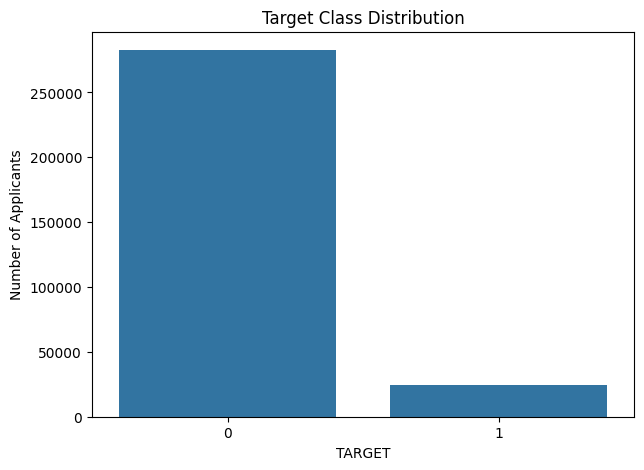

In [8]:
plt.figure(figsize=(7, 5))

sns.countplot(
    data=application,
    x="TARGET"
)

plt.title("Target Class Distribution")
plt.xlabel("TARGET")
plt.ylabel("Number of Applicants")
plt.show()

### EDA Takeaway

The TARGET variable shows the distribution between applicants who did not default (0) and applicants who defaulted (1). The distribution should be checked for class imbalance before model training.

In [9]:
missing = (
    application.isna()
    .sum()
    .to_frame("missing_count")
)

missing["missing_pct"] = (
    missing["missing_count"]
    / len(application)
    * 100
)

missing = (
    missing[missing["missing_count"] > 0]
    .sort_values("missing_pct", ascending=False)
)

missing.head(20)

,missing_count,missing_pct
COMMONAREA_MEDI,214865,69.872297
COMMONAREA_MODE,214865,69.872297
COMMONAREA_AVG,214865,69.872297
NONLIVINGAPARTMENTS_MODE,213514,69.432963
NONLIVINGAPARTMENTS_MEDI,213514,69.432963
NONLIVINGAPARTMENTS_AVG,213514,69.432963
FONDKAPREMONT_MODE,210295,68.386172
LIVINGAPARTMENTS_AVG,210199,68.354953
LIVINGAPARTMENTS_MEDI,210199,68.354953
LIVINGAPARTMENTS_MODE,210199,68.354953


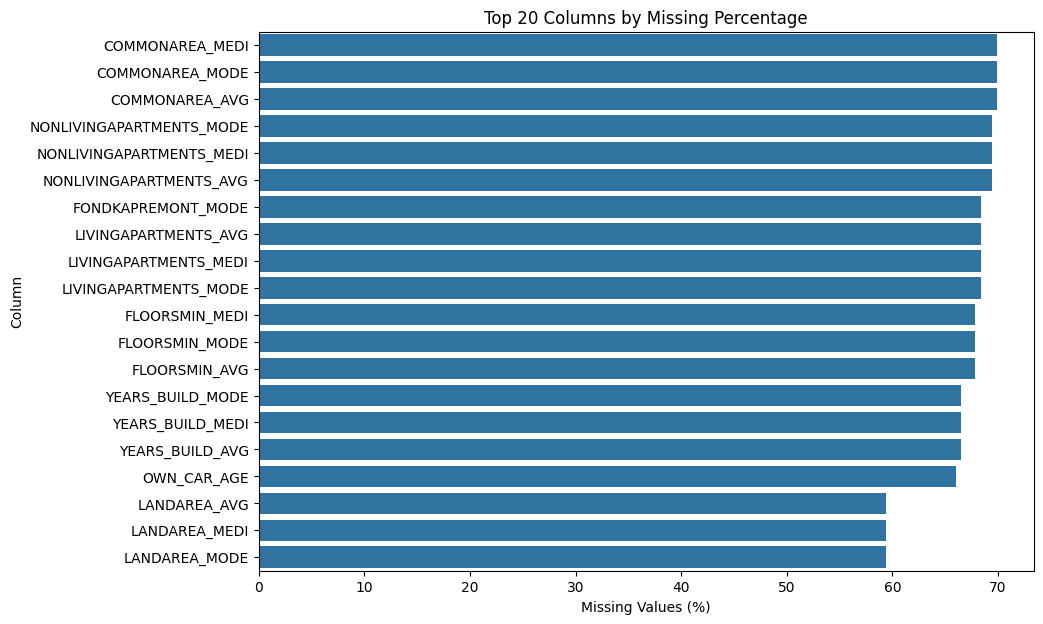

In [10]:
plt.figure(figsize=(10, 7))

sns.barplot(
    data=missing.head(20),
    x="missing_pct",
    y=missing.head(20).index
)

plt.title("Top 20 Columns by Missing Percentage")
plt.xlabel("Missing Values (%)")
plt.ylabel("Column")
plt.show()

### EDA Takeaway

Several application variables contain substantial missing values. Missingness is not automatically treated as noise because, in the Home Credit dataset, the absence of information can itself indicate characteristics of an applicant's credit history.

In [11]:
days_employed_counts = (
    application["DAYS_EMPLOYED"]
    .value_counts()
    .head(10)
)

days_employed_counts

DAYS_EMPLOYED
 365243    55374
-200         156
-224         152
-230         151
-199         151
-212         150
-384         143
-229         143
-231         140
-207         138
Name: count, dtype: int64

In [12]:
anomaly_count = (
    application["DAYS_EMPLOYED"] == 365243
).sum()

anomaly_pct = (
    anomaly_count / len(application) * 100
)

print("Placeholder count:", anomaly_count)
print(f"Placeholder percentage: {anomaly_pct:.2f}%")


Placeholder count: 55374
Placeholder percentage: 18.01%


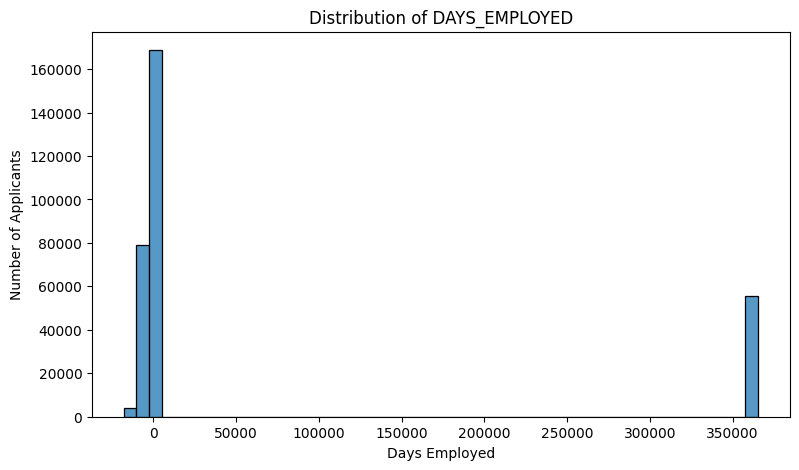

In [13]:
plt.figure(figsize=(9, 5))

sns.histplot(
    data=application,
    x="DAYS_EMPLOYED",
    bins=50
)

plt.title("Distribution of DAYS_EMPLOYED")
plt.xlabel("Days Employed")
plt.ylabel("Number of Applicants")
plt.show()

### EDA Takeaway

`DAYS_EMPLOYED` contains the placeholder value 365243, which does not represent a realistic employment duration and must be handled later during preprocessing to prevent the model from learning an artificial pattern.

In [14]:
numeric_columns = application.select_dtypes(include=np.number).columns

correlations = (
    application[numeric_columns]
    .corr()["TARGET"]
    .drop("TARGET")
    .sort_values(key=abs, ascending=False)
)

correlations.head(10)

EXT_SOURCE_3                  -0.178919
EXT_SOURCE_2                  -0.160472
EXT_SOURCE_1                  -0.155317
DAYS_BIRTH                     0.078239
REGION_RATING_CLIENT_W_CITY    0.060893
REGION_RATING_CLIENT           0.058899
DAYS_LAST_PHONE_CHANGE         0.055218
DAYS_ID_PUBLISH                0.051457
REG_CITY_NOT_WORK_CITY         0.050994
FLAG_EMP_PHONE                 0.045982
Name: TARGET, dtype: float64

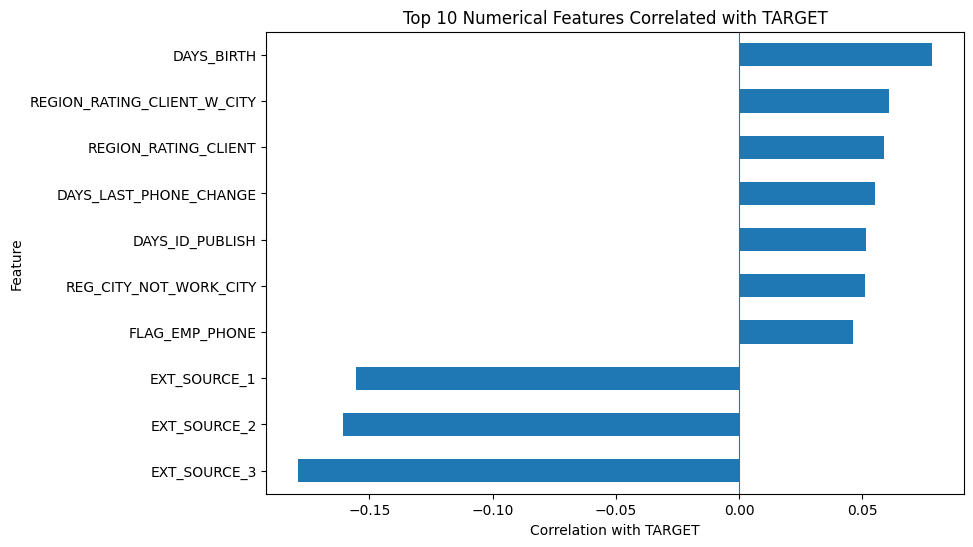

In [15]:
top_correlations = correlations.head(10).sort_values()

plt.figure(figsize=(9, 6))

top_correlations.plot(kind="barh")

plt.title("Top 10 Numerical Features Correlated with TARGET")
plt.xlabel("Correlation with TARGET")
plt.ylabel("Feature")
plt.axvline(0, linewidth=0.8)
plt.show()

### EDA Takeaway

The three EXT_SOURCE variables have the strongest numerical association with TARGET, with higher external scores generally associated with lower default risk. Other variables show weaker relationships, demonstrating that default risk is influenced by multiple factors rather than a single feature.

In [16]:
categorical_columns = application.select_dtypes(
    include=["object"]
).columns

print("Number of categorical columns:", len(categorical_columns))
print("\nCategorical columns:")
print(categorical_columns.tolist())

Number of categorical columns: 16

Categorical columns:
['NAME_CONTRACT_TYPE', 'CODE_GENDER', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'NAME_TYPE_SUITE', 'NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE', 'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE', 'OCCUPATION_TYPE', 'WEEKDAY_APPR_PROCESS_START', 'ORGANIZATION_TYPE', 'FONDKAPREMONT_MODE', 'HOUSETYPE_MODE', 'WALLSMATERIAL_MODE', 'EMERGENCYSTATE_MODE']


In [17]:
education_default_rate = (
    application.groupby("NAME_EDUCATION_TYPE")["TARGET"]
    .mean()
    .sort_values(ascending=False)
    .mul(100)
)

education_default_rate

NAME_EDUCATION_TYPE
Lower secondary                  10.927673
Secondary / secondary special     8.939929
Incomplete higher                 8.484966
Higher education                  5.355115
Academic degree                   1.829268
Name: TARGET, dtype: float64

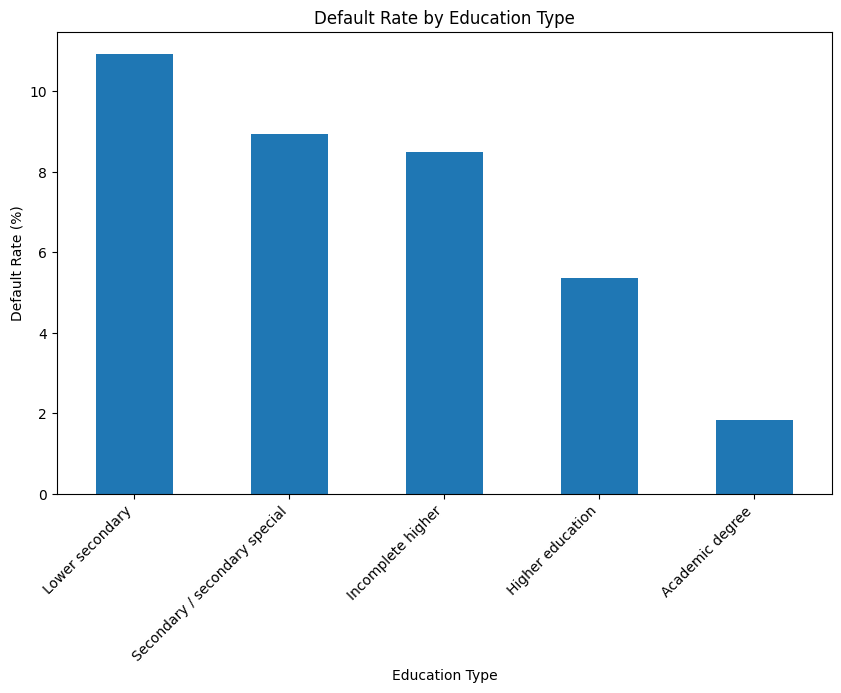

In [18]:
plt.figure(figsize=(10, 6))

education_default_rate.plot(kind="bar")

plt.title("Default Rate by Education Type")
plt.xlabel("Education Type")
plt.ylabel("Default Rate (%)")
plt.xticks(rotation=45, ha="right")
plt.show()

### EDA Takeaway

Default rates vary across education categories, indicating that education type may contain useful information about applicant risk. These differences are associations observed in the dataset and do not by themselves establish causation.

In [19]:
income_default_rate = (
    application.groupby("NAME_INCOME_TYPE")["TARGET"]
    .mean()
    .sort_values(ascending=False)
    .mul(100)
)

income_default_rate

NAME_INCOME_TYPE
Maternity leave         40.000000
Unemployed              36.363636
Working                  9.588472
Commercial associate     7.484257
State servant            5.754965
Pensioner                5.386366
Businessman              0.000000
Student                  0.000000
Name: TARGET, dtype: float64

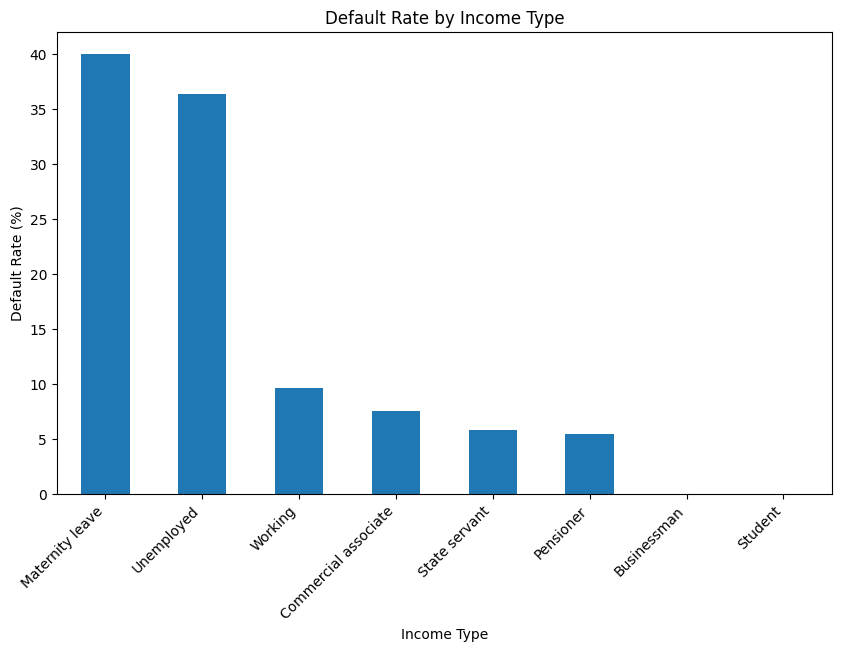

In [20]:
plt.figure(figsize=(10, 6))

income_default_rate.plot(kind="bar")

plt.title("Default Rate by Income Type")
plt.xlabel("Income Type")
plt.ylabel("Default Rate (%)")
plt.xticks(rotation=45, ha="right")
plt.show()

In [21]:
income_summary = (
    application.groupby("NAME_INCOME_TYPE")
    .agg(
        applicants=("TARGET", "count"),
        defaults=("TARGET", "sum"),
        default_rate=("TARGET", "mean")
    )
)

income_summary["default_rate"] = (
    income_summary["default_rate"] * 100
)

income_summary.sort_values(
    "default_rate",
    ascending=False
)

,applicants,defaults,default_rate
NAME_INCOME_TYPE,,,
Maternity leave,5,2,40.000000
Unemployed,22,8,36.363636
Working,158774,15224,9.588472
Commercial associate,71617,5360,7.484257
State servant,21703,1249,5.754965
Pensioner,55362,2982,5.386366
Businessman,10,0,0.000000
Student,18,0,0.000000


### EDA Takeaway

Default rates vary across income types. However, very small groups such as Maternity leave and Unemployed have high observed default rates but very few applicants, so these percentages should be interpreted cautiously. Larger groups such as Working and Commercial associate provide more reliable descriptive comparisons.

In [22]:
gender_summary = (
    application.groupby("CODE_GENDER")
    .agg(
        applicants=("TARGET", "count"),
        defaults=("TARGET", "sum"),
        default_rate=("TARGET", "mean")
    )
)

gender_summary["default_rate"] = (
    gender_summary["default_rate"] * 100
)

gender_summary

,applicants,defaults,default_rate
CODE_GENDER,,,
F,202448,14170,6.999328
M,105059,10655,10.141920
XNA,4,0,0.000000


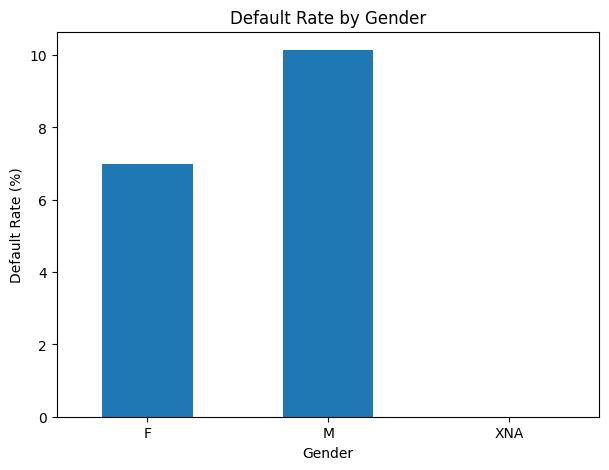

In [23]:
plt.figure(figsize=(7, 5))

gender_summary["default_rate"].plot(kind="bar")

plt.title("Default Rate by Gender")
plt.xlabel("Gender")
plt.ylabel("Default Rate (%)")
plt.xticks(rotation=0)
plt.show()

### EDA Takeaway

The observed default rate differs between gender categories, with male applicants showing a higher default rate than female applicants in this dataset. The XNA category is extremely rare, so its observed rate should not be interpreted strongly.

In [24]:
ownership_summary = pd.DataFrame({
    "Car Ownership": application.groupby("FLAG_OWN_CAR")["TARGET"].mean() * 100,
    "Property Ownership": application.groupby("FLAG_OWN_REALTY")["TARGET"].mean() * 100
})

ownership_summary

,Car Ownership,Property Ownership
N,8.500227,8.324929
Y,7.243730,7.961577


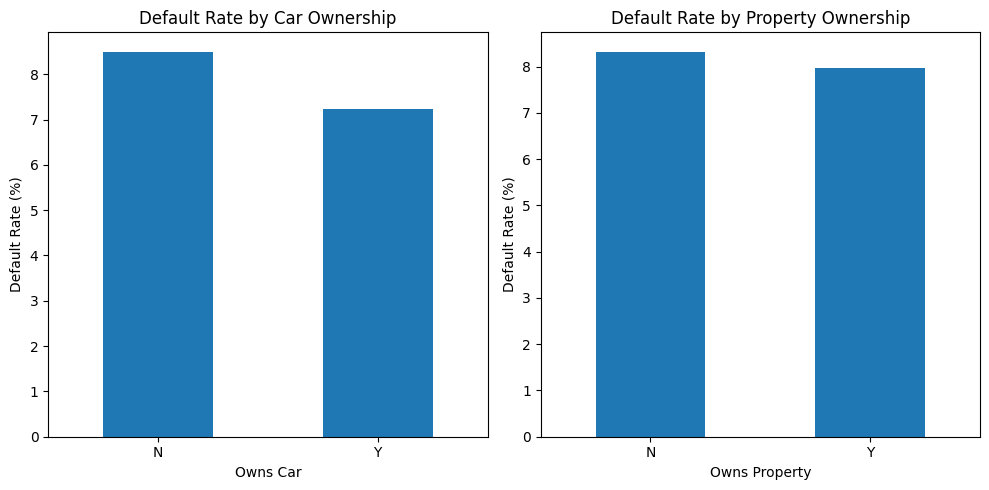

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

application.groupby("FLAG_OWN_CAR")["TARGET"].mean().mul(100).plot(
    kind="bar",
    ax=axes[0]
)

axes[0].set_title("Default Rate by Car Ownership")
axes[0].set_xlabel("Owns Car")
axes[0].set_ylabel("Default Rate (%)")
axes[0].tick_params(axis="x", rotation=0)

application.groupby("FLAG_OWN_REALTY")["TARGET"].mean().mul(100).plot(
    kind="bar",
    ax=axes[1]
)

axes[1].set_title("Default Rate by Property Ownership")
axes[1].set_xlabel("Owns Property")
axes[1].set_ylabel("Default Rate (%)")
axes[1].tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.show()

### EDA Takeaway

Default rates can be compared between applicants who do and do not own a car or property. These ownership variables may provide useful descriptive information about applicant characteristics, but the observed differences do not establish causation.

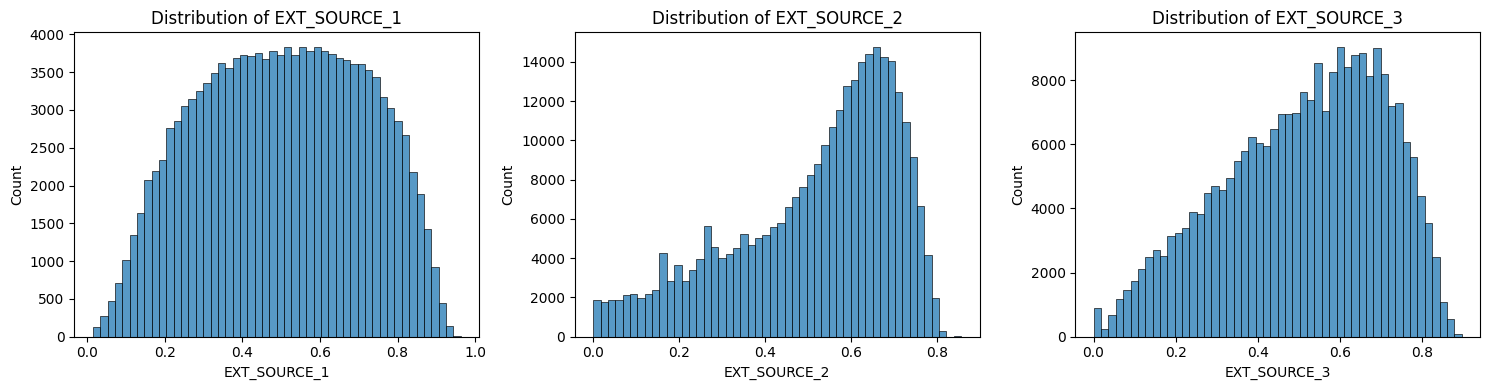

In [26]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, column in zip(
    axes,
    ["EXT_SOURCE_1", "EXT_SOURCE_2", "EXT_SOURCE_3"]
):
    sns.histplot(
        data=application,
        x=column,
        bins=50,
        ax=ax
    )
    
    ax.set_title(f"Distribution of {column}")
    ax.set_xlabel(column)
    ax.set_ylabel("Count")

plt.tight_layout()
plt.show()

### EDA Takeaway

The three EXT_SOURCE variables have values mostly between 0 and 1, but their distributions have different shapes. They also have missing values and show relatively strong associations with TARGET, making them important candidate features for later modeling.

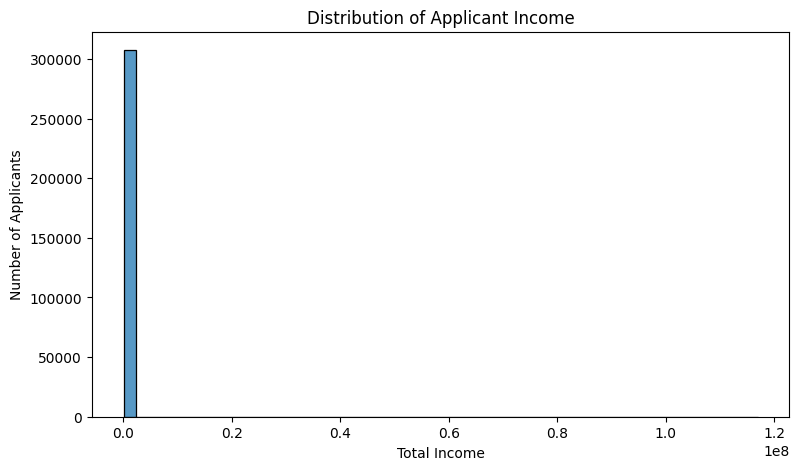

In [27]:
plt.figure(figsize=(9, 5))

sns.histplot(
    data=application,
    x="AMT_INCOME_TOTAL",
    bins=50
)

plt.title("Distribution of Applicant Income")
plt.xlabel("Total Income")
plt.ylabel("Number of Applicants")
plt.show()

In [28]:
income_percentiles = application["AMT_INCOME_TOTAL"].describe(
    percentiles=[0.50, 0.75, 0.90, 0.95, 0.99]
)

income_percentiles

count    3.075110e+05
mean     1.687979e+05
std      2.371231e+05
min      2.565000e+04
50%      1.471500e+05
75%      2.025000e+05
90%      2.700000e+05
95%      3.375000e+05
99%      4.725000e+05
max      1.170000e+08
Name: AMT_INCOME_TOTAL, dtype: float64

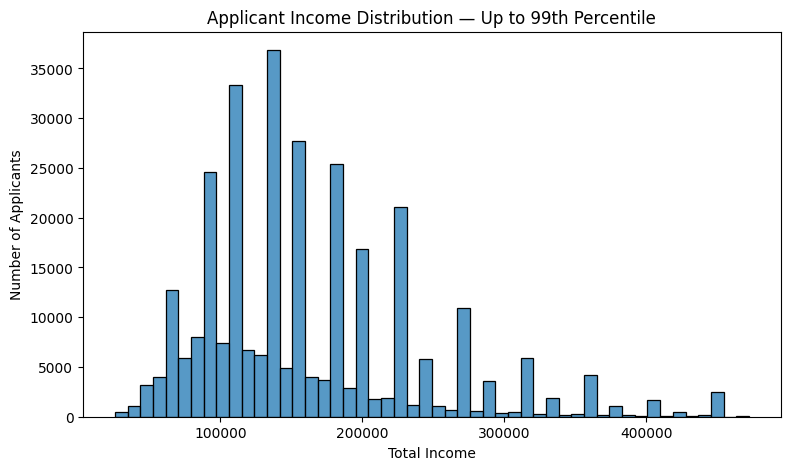

In [30]:
plt.figure(figsize=(9, 5))

sns.histplot(
    data=application[
        application["AMT_INCOME_TOTAL"] <= application["AMT_INCOME_TOTAL"].quantile(0.99)
    ],
    x="AMT_INCOME_TOTAL",
    bins=50
)

plt.title("Applicant Income Distribution — Up to 99th Percentile")
plt.xlabel("Total Income")
plt.ylabel("Number of Applicants")

plt.show()

### EDA Takeaway

AMT_INCOME_TOTAL is strongly right-skewed. The median income is 147,150 and 99% of applicants have income below 472,500, while the maximum is 117,000,000. This indicates the presence of extreme income values that should be considered during later feature engineering.

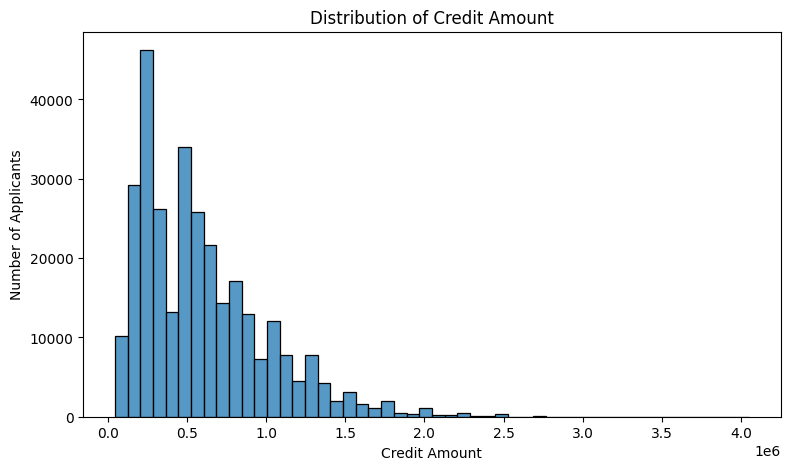

In [31]:
plt.figure(figsize=(9, 5))

sns.histplot(
    data=application,
    x="AMT_CREDIT",
    bins=50
)

plt.title("Distribution of Credit Amount")
plt.xlabel("Credit Amount")
plt.ylabel("Number of Applicants")

plt.show()

In [32]:
credit_percentiles = application["AMT_CREDIT"].describe(
    percentiles=[0.50, 0.75, 0.90, 0.95, 0.99]
)

credit_percentiles

count    3.075110e+05
mean     5.990260e+05
std      4.024908e+05
min      4.500000e+04
50%      5.135310e+05
75%      8.086500e+05
90%      1.133748e+06
95%      1.350000e+06
99%      1.854000e+06
max      4.050000e+06
Name: AMT_CREDIT, dtype: float64

### EDA Takeaway

AMT_CREDIT is right-skewed, with most applicants requesting moderate credit amounts. The median credit amount is 513,531, while 99% of applicants have requested 1,854,000 or less and the maximum is 4,050,000. The distribution contains higher-value applications that should be considered during later preprocessing.

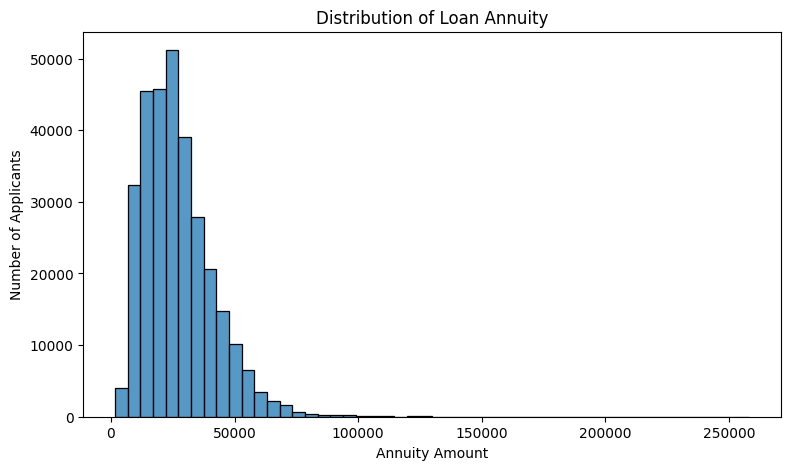

In [33]:
plt.figure(figsize=(9, 5))

sns.histplot(
    data=application,
    x="AMT_ANNUITY",
    bins=50
)

plt.title("Distribution of Loan Annuity")
plt.xlabel("Annuity Amount")
plt.ylabel("Number of Applicants")

plt.show()

In [34]:
annuity_percentiles = application["AMT_ANNUITY"].describe(
    percentiles=[0.50, 0.75, 0.90, 0.95, 0.99]
)

annuity_percentiles

count    307499.000000
mean      27108.573909
std       14493.737315
min        1615.500000
50%       24903.000000
75%       34596.000000
90%       45954.000000
95%       53325.000000
99%       70006.500000
max      258025.500000
Name: AMT_ANNUITY, dtype: float64

### EDA Takeaway

AMT_ANNUITY is right-skewed, with a median value of 24,903. Most applicants have annuity amounts below 70,006.50, while the maximum reaches 258,025.50. The variable also contains a small number of missing values, which will be handled during later preprocessing.

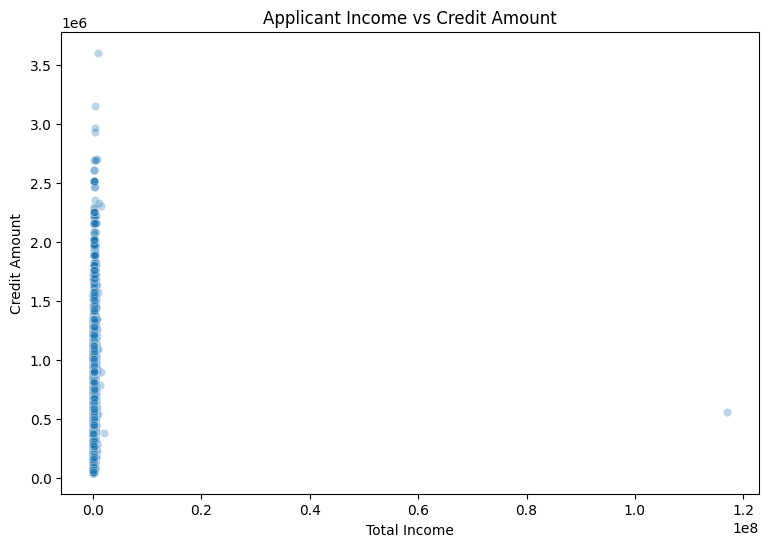

In [35]:
sample = application.sample(
    n=10_000,
    random_state=42
)

plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=sample,
    x="AMT_INCOME_TOTAL",
    y="AMT_CREDIT",
    alpha=0.3
)

plt.title("Applicant Income vs Credit Amount")
plt.xlabel("Total Income")
plt.ylabel("Credit Amount")

plt.show()

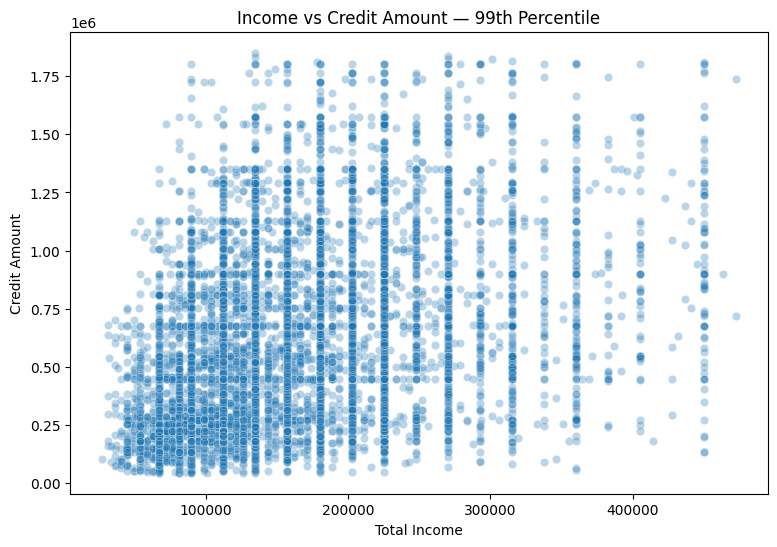

In [36]:
income_99 = application["AMT_INCOME_TOTAL"].quantile(0.99)
credit_99 = application["AMT_CREDIT"].quantile(0.99)

sample_filtered = application[
    (application["AMT_INCOME_TOTAL"] <= income_99) &
    (application["AMT_CREDIT"] <= credit_99)
].sample(
    n=10_000,
    random_state=42
)

plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=sample_filtered,
    x="AMT_INCOME_TOTAL",
    y="AMT_CREDIT",
    alpha=0.3
)

plt.title("Income vs Credit Amount — 99th Percentile")
plt.xlabel("Total Income")
plt.ylabel("Credit Amount")

plt.show()

### EDA Takeaway

The scatter plot shows a general positive relationship between applicant income and requested credit amount: higher-income applicants tend to request larger amounts of credit. However, substantial variation exists, indicating that income alone does not determine the requested credit amount. Extreme values were excluded only from this visualization to improve readability.

In [37]:
missing_summary = (
    application.isnull()
    .sum()
    .sort_values(ascending=False)
)

missing_summary.head(20)

COMMONAREA_AVG              214865
COMMONAREA_MODE             214865
COMMONAREA_MEDI             214865
NONLIVINGAPARTMENTS_MEDI    213514
NONLIVINGAPARTMENTS_MODE    213514
NONLIVINGAPARTMENTS_AVG     213514
FONDKAPREMONT_MODE          210295
LIVINGAPARTMENTS_AVG        210199
LIVINGAPARTMENTS_MEDI       210199
LIVINGAPARTMENTS_MODE       210199
FLOORSMIN_MODE              208642
FLOORSMIN_AVG               208642
FLOORSMIN_MEDI              208642
YEARS_BUILD_AVG             204488
YEARS_BUILD_MODE            204488
YEARS_BUILD_MEDI            204488
OWN_CAR_AGE                 202929
LANDAREA_MEDI               182590
LANDAREA_AVG                182590
LANDAREA_MODE               182590
dtype: int64

In [38]:
missing_pct = (
    application.isnull().mean() * 100
).sort_values(ascending=False)

missing_pct.head(20)

COMMONAREA_AVG              69.872297
COMMONAREA_MODE             69.872297
COMMONAREA_MEDI             69.872297
NONLIVINGAPARTMENTS_MEDI    69.432963
NONLIVINGAPARTMENTS_MODE    69.432963
NONLIVINGAPARTMENTS_AVG     69.432963
FONDKAPREMONT_MODE          68.386172
LIVINGAPARTMENTS_AVG        68.354953
LIVINGAPARTMENTS_MEDI       68.354953
LIVINGAPARTMENTS_MODE       68.354953
FLOORSMIN_MODE              67.848630
FLOORSMIN_AVG               67.848630
FLOORSMIN_MEDI              67.848630
YEARS_BUILD_AVG             66.497784
YEARS_BUILD_MODE            66.497784
YEARS_BUILD_MEDI            66.497784
OWN_CAR_AGE                 65.990810
LANDAREA_MEDI               59.376738
LANDAREA_AVG                59.376738
LANDAREA_MODE               59.376738
dtype: float64

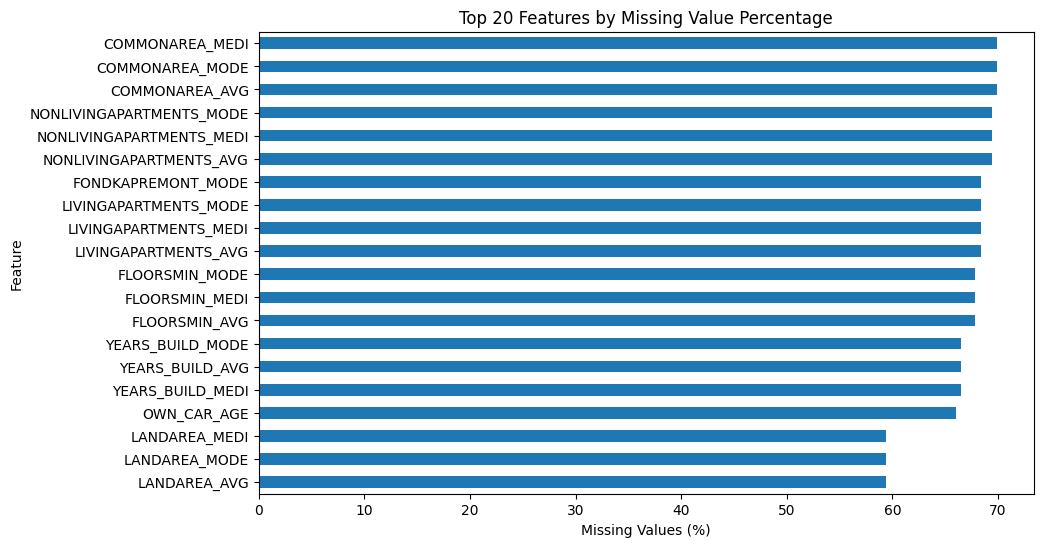

In [39]:
plt.figure(figsize=(10, 6))

missing_pct.head(20).sort_values().plot(kind="barh")

plt.title("Top 20 Features by Missing Value Percentage")
plt.xlabel("Missing Values (%)")
plt.ylabel("Feature")

plt.show()

### EDA Takeaway

Several property-related and vehicle-related features have substantial missing values. The highest missingness is observed in COMMONAREA_AVG at approximately 69.87%, followed by NONLIVINGAPARTMENTS_AVG at 69.43% and FONDKAPREMONT_MODE at 68.39%. These high-missingness features will require careful handling during the preprocessing stage.

In [40]:
duplicate_ids = application["SK_ID_CURR"].duplicated().sum()

print("Duplicate applicant IDs:", duplicate_ids)
print("Total applicants:", len(application))
print("Unique applicants:", application["SK_ID_CURR"].nunique())

Duplicate applicant IDs: 0
Total applicants: 307511
Unique applicants: 307511


### EDA Takeaway

The application_train table contains no duplicate applicant IDs. Each applicant is represented by a unique SK_ID_CURR, so no duplicate records need to be removed from the main application dataset.

# Final EDA Summary

## Key Findings

1. The TARGET variable is imbalanced:
   - TARGET = 0: 91.93%
   - TARGET = 1: 8.07%

2. DAYS_EMPLOYED contains the placeholder value 365243 for 55,374 applicants (18.01%). This value does not represent a realistic employment duration and will require treatment during preprocessing.

3. Several features contain substantial missing values. COMMONAREA_AVG, COMMONAREA_MODE, and COMMONAREA_MEDI have approximately 69.87% missing values.

4. EXT_SOURCE_1, EXT_SOURCE_2, and EXT_SOURCE_3 have the strongest numerical associations with TARGET among the analyzed variables.

5. AMT_INCOME_TOTAL is strongly right-skewed and contains extreme values. Its maximum is 117,000,000 while 99% of applicants have income below 472,500.

6. AMT_CREDIT is right-skewed. The median credit amount is 513,531 and the maximum is 4,050,000.

7. AMT_ANNUITY is also right-skewed. The median annuity is 24,903 and the maximum is 258,025.50.

8. Default rates differ across several categorical groups, including education, income type, gender, car ownership, and property ownership. Small categories should be interpreted cautiously.

9. Income and requested credit show a general positive relationship, although substantial variation exists between applicants.

10. No duplicate SK_ID_CURR values were found in application_train.

## EDA Conclusion

The dataset contains class imbalance, substantial missingness, placeholder values, skewed numerical variables, and potentially informative categorical and numerical relationships. These findings will guide the preprocessing and feature-engineering decisions in the next phase.

No permanent data cleaning, imputation, SMOTE, or feature transformation was performed during EDA.